<img src="./assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Lab: Simple Linear Regression with Sacramento Real Estate Data

---

In this lab you will hone your exploratory data analysis (EDA) skills and practice constructing linear regressions on a data set of Sacramento real estate sales.  The data set contains information on qualities of the property, location of the property, and time of sale.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

### 1. Read in the Sacramento housing data set.

The file is stored in the `data` subfolder.

In [2]:
housing = pd.read_csv('./data/sacramento_real_estate_transactions.csv')

In [3]:
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.519470,-121.435768


### 2. Conduct exploratory data analysis on this data set. 

If you discover any issues with the data, fix them to the best of your ability. Report any notable findings.

__Note:__
- Assign the correct data type to each column.
- Look for missing values and determine how to handle them. Keep in mind that most machine learning models cannot process null values.
- Check the value ranges for numerical and categorical columns to identify any anomalies.
- Examine the distribution of values and investigate potential outliers.

In [4]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   street     985 non-null    str    
 1   city       985 non-null    str    
 2   zip        985 non-null    int64  
 3   state      985 non-null    str    
 4   beds       985 non-null    int64  
 5   baths      985 non-null    int64  
 6   sq__ft     985 non-null    int64  
 7   type       985 non-null    str    
 8   sale_date  985 non-null    str    
 9   price      985 non-null    int64  
 10  latitude   985 non-null    float64
 11  longitude  985 non-null    float64
dtypes: float64(2), int64(5), str(5)
memory usage: 156.9 KB


In [5]:
housing['sale_date'] = pd.to_datetime(housing['sale_date'], format="%a %b %d %H:%M:%S EDT %Y")

In [6]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   street     985 non-null    str           
 1   city       985 non-null    str           
 2   zip        985 non-null    int64         
 3   state      985 non-null    str           
 4   beds       985 non-null    int64         
 5   baths      985 non-null    int64         
 6   sq__ft     985 non-null    int64         
 7   type       985 non-null    str           
 8   sale_date  985 non-null    datetime64[us]
 9   price      985 non-null    int64         
 10  latitude   985 non-null    float64       
 11  longitude  985 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(5), str(4)
memory usage: 129.9 KB


In [7]:
housing.isnull().sum()

street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64

In [8]:
housing.duplicated().sum()

np.int64(3)

In [9]:
housing.drop_duplicates(inplace=True)
housing.duplicated().sum()

np.int64(0)

In [10]:
housing.describe()

,zip,beds,baths,sq__ft,sale_date,price,latitude,longitude
count,982.000000,982.000000,982.000000,982.000000,982,982.000000,982.000000,982.000000
mean,95750.863544,2.914460,1.779022,1314.776986,2008-05-18 05:09:24.562118,234185.358452,38.444300,-121.192904
min,95603.000000,0.000000,0.000000,-984.000000,2008-05-15 00:00:00,-210944.000000,-121.503471,-121.551704
25%,95660.250000,2.000000,1.000000,953.000000,2008-05-16 00:00:00,145000.000000,38.482337,-121.446104
50%,95762.000000,3.000000,2.000000,1304.500000,2008-05-19 00:00:00,215000.000000,38.625611,-121.376010
75%,95828.000000,4.000000,2.000000,1719.500000,2008-05-20 00:00:00,300000.000000,38.694512,-121.295114
max,95864.000000,8.000000,5.000000,5822.000000,2008-05-21 00:00:00,884790.000000,39.020808,38.668433
std,85.113618,1.305838,0.894568,856.266836,NaN,138992.002773,5.111407,5.108454


In [11]:
housing = housing[(housing['sq__ft'] > 0) & (housing['price'] > 0)]
housing.describe()

,zip,beds,baths,sq__ft,sale_date,price,latitude,longitude
count,811.000000,811.000000,811.000000,811.000000,811,811.000000,811.000000,811.000000
mean,95761.501850,3.247842,1.963009,1593.212084,2008-05-18 04:58:17.903822,229746.900123,38.576806,-121.378543
min,95603.000000,1.000000,1.000000,484.000000,2008-05-15 00:00:00,2000.000000,38.241514,-121.550527
25%,95670.000000,3.000000,2.000000,1145.000000,2008-05-16 00:00:00,148750.000000,38.473794,-121.451482
50%,95820.000000,3.000000,2.000000,1420.000000,2008-05-19 00:00:00,208000.000000,38.591618,-121.404999
75%,95828.000000,4.000000,2.000000,1853.500000,2008-05-20 00:00:00,285000.000000,38.674545,-121.325958
max,95864.000000,8.000000,5.000000,5822.000000,2008-05-21 00:00:00,884790.000000,39.008159,-120.597599
std,85.295425,0.848516,0.669337,664.102137,NaN,119891.141884,0.126406,0.119818


In [12]:
housing['type'].value_counts()

type
Residential     757
Condo            41
Multi-Family     13
Name: count, dtype: int64

When you've finished cleaning or have made a good deal of progress cleaning, it's always a good idea to save your work. Use the pandas `to_csv` method to export your cleaned dataset.

```python
# example -- your dataframe name may be different
dataframe.to_csv('./datasets/sacramento_cleaned_dataframe.csv', index=False)

```

In [13]:
housing.to_csv('./data/sacramento_cleaned_dataframe.csv',index=False)

### 3. Our goal will be to predict price. List variables that you think qualify as predictors of price in an SLR model.

For each of the variables you believe should be considered, generate a plot showing the relationship between the independent and dependent variables.

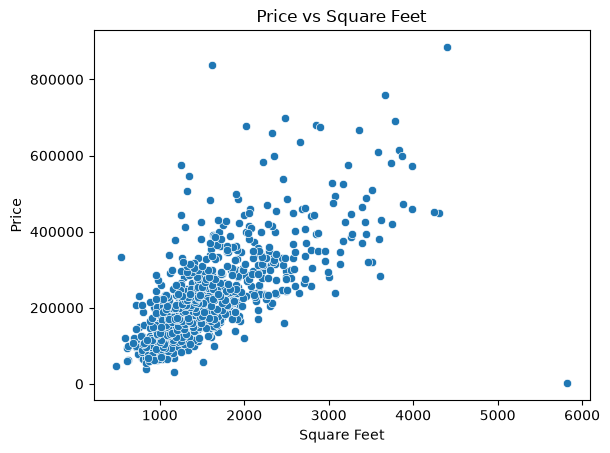

In [14]:
sns.scatterplot(
    data=housing,
    x='sq__ft',
    y='price'
)

plt.title("Price vs Square Feet")
plt.xlabel("Square Feet")
plt.ylabel("Price")

plt.show()

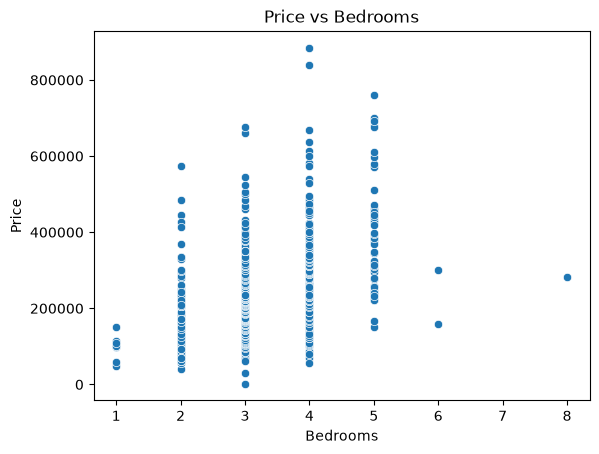

In [15]:
sns.scatterplot(
    data=housing,
    x='beds',
    y='price'
)

plt.title("Price vs Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price")

plt.show()

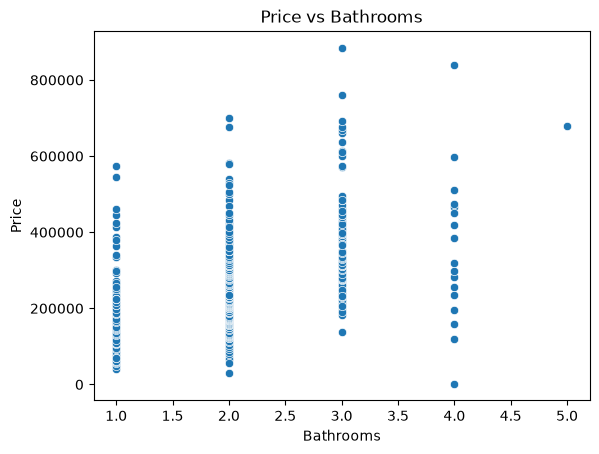

In [16]:
sns.scatterplot(
    data=housing,
    x='baths',
    y='price'
)

plt.title("Price vs Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Price")

plt.show()

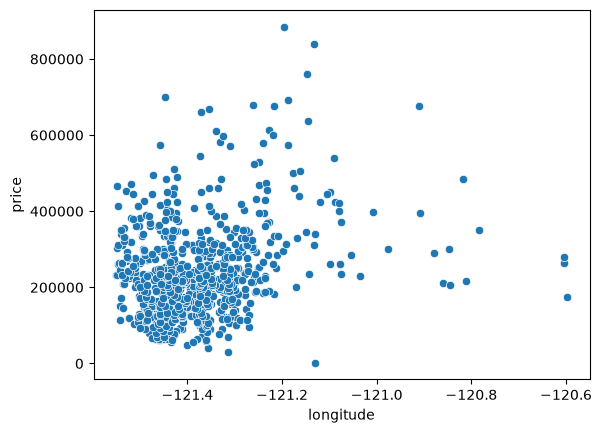

In [17]:
sns.scatterplot(
    data=housing,
    x='longitude',
    y='price'
)

plt.show()

### 4. Which variable would be the best predictor of Y in an SLR model? Why?

In [18]:
X = housing[['sq__ft']]
y = housing['price']

#Potential predictors of house price include square footage, number of bedrooms, number of bathrooms,
#and location variables. Among these variables, square footage appears to have the strongest linear relationship with price,
#therefore it will be considered as the main predictor for the simple linear regression model.

### 5. Write a function that will take in two lists, `x` and `y`, and return the intercept and slope coefficients that minimize SSE. 

`y` is the target variable, and `x` is the predictor variable.

**Don't use `scikit-learn` for this**. Instead, use `numpy`.

The slope and intercept of simple linear regression can be calculated by using certain summary statistics. In particular, we'll need to know:

- $\bar{x}$, the mean of `x`
- $\bar{y}$, the mean of `y`
- $s_{x}$, the standard deviation of `x`
- $s_{y}$, the standard deviation of `y`
- $r_{xy}$, the correlation of `x` and `y`

Given these summary statistics, the **coefficient on `X`** (or the slope) can be given by $\beta_{1} = r_{xy} * \frac{s_{y}}{s_{x}}$. The **intercept of the model** can be given by $\beta_{0} = \bar{y} - \beta_{1}\bar{x}$.

Your function should take in `x` and `y`, then use the above summary statistics to calculate the slope and intercept.

- **Test your function on price and the variable you determined was the best predictor in Problem 4.**
- **Report the slope and intercept.**

In [19]:
import numpy as np

def calculate_slope_intercept(x, y):

    # convert lists to numpy arrays
    x = np.array(x)
    y = np.array(y)

    # mean
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    # standard deviation
    x_std = np.std(x)
    y_std = np.std(y)

    # correlation between x and y
    correlation = np.corrcoef(x, y)[0,1]

    # calculate slope
    slope = correlation * (y_std / x_std)

    # calculate intercept
    intercept = y_mean - slope * x_mean

    return intercept, slope

In [20]:
x = housing['sq__ft']
y = housing['price']

intercept, slope = calculate_slope_intercept(x, y)

print("Intercept:", intercept)
print("Slope:", slope)

Intercept: 30352.243076665123
Slope: 125.15261406074985


### 6. Interpret the intercept and the slope.

In [21]:
#The intercept is 30,352.24, which represents the predicted house price when square footage is zero.
#This value does not have a practical meaning because a house cannot have zero square feet, but it is needed to define the regression line.


#The slope is 125.15, meaning that for every additional square foot, the predicted house price increases by approximately $125.15.

### 7. Give an example of how this model could be used for prediction and how it could be used for inference. 

**Be sure to make it clear which example is associated with prediction and which is associated with inference.**

In [22]:
# The intercept is 30,352.24, which represents the predicted price when square footage is zero. Although this value is not realistic, it is required for the regression equation.
# The slope is 125.15, meaning that each additional square foot increases the predicted house price by approximately $125.15.
# Prediction: The model can be used to estimate the price of a new house using its square footage.
# Inference: The model helps us understand the relationship between house size and price, showing that larger houses generally have higher prices.

### 8: [Bonus] Using the model you came up with in Problem 5, calculate and plot the residuals.

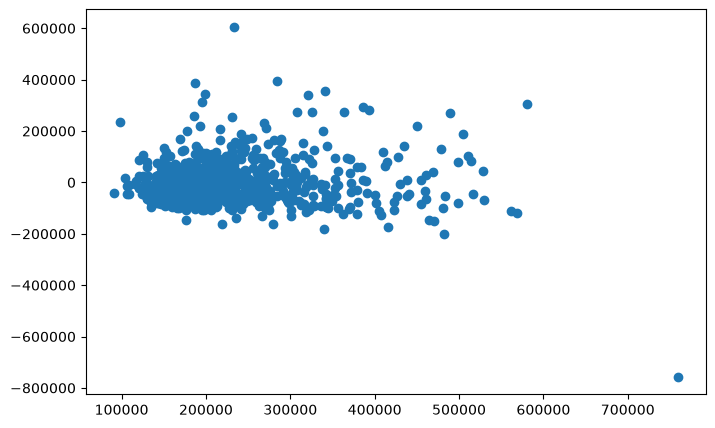

In [23]:
# Calculate predicted prices
predicted_price = intercept + slope * x

# Calculate residuals
residuals = y - predicted_price

# Plot residuals
plt.figure(figsize=(8,5))

plt.scatter(
    predicted_price,
    residuals
)


plt.show()

---

## Dummy Variables

It is important to be cautious with categorical variables, which represent distict groups or categories, when building a regression. If put in a regression "as-is," categorical variables represented as integers will be treated like *continuous* variables.

That is to say, instead of group "3" having a different effect on the estimation than group "1" it will estimate literally 3 times more than group 1. 

For example, if occupation category "1" represents "analyst" and occupation category "3" represents "barista", and our target variable is salary, if we leave this as a column of integers then barista will always have `beta*3` the effect of analyst.

This will almost certainly force the beta coefficient to be something strange and incorrect. Instead, we can re-represent the categories as multiple "dummy coded" columns.



#### A Word of Caution When Creating Dummies

Let's touch on precautions we should take when dummy coding.

**If you convert a qualitative variable to dummy variables, you want to turn a variable with N categories into N-1 variables.**

> **Scenario 1:** Suppose we're working with the variable "sex" or "gender" with values "M" and "F". 

You should include in your model only one variable for "sex = F" which takes on 1 if sex is female and 0 if sex is not female! Rather than saying "a one unit change in X," the coefficient associated with "sex = F" is interpreted as the average change in Y when sex = F relative to when sex = M.

| Female | Male | 
|-------|------|
| 0 | 1 | 
| 1 | 0 |
| 0 | 1 |
| 1 | 0 |
| 1 | 0 |
_As we can see a 1 in the female column indicates a 0 in the male column. And so, we have two columns stating the same information in different ways._

> Scenario 2: Suppose we're modeling revenue at a bar for each of the days of the week. We have a column with strings identifying which day of the week this observation occured in.

We might include six of the days as their own variables: "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday". **But not all 7 days.**  

|Monday | Tuesday | Wednesday | Thursday | Friday | Saturday | 
|-------|---------|-----------|----------|--------|----------|
| 1     | 0       |0          |      0   |0       | 0        | 
| 0     | 1       |0          |      0   |0       | 0        | 
| 0     | 0       |1          |      0   |0       | 0        | 
| 0     | 0       |0          |      1   |0       | 0        | 
| 0     | 0       |0          |      0   |1       | 0        | 
| 0     | 0       |0          |      0   |0       | 1        | 
| 0     | 0       |0          |      0   |0       | 0        | 

_As humans we can infer from the last row that if its is not Monday, Tuesday, Wednesday, Thursday, Friday or Saturday, it must be Sunday. Models work the same way._

The coefficient for Monday is then interpreted as the average change in revenue when "day = Monday" relative to "day = Sunday." The coefficient for Tuesday is interpreted as the average change in revenue when "day = Tuesday" relative to "day = Sunday" and so on.

The category you leave out, which the other columns are *relative to*, is often referred to as the **reference category**.

### 9. Use the `pd.get_dummies` function to convert the `type` column into dummy-coded variables.

In [26]:
type_dummies = pd.get_dummies(housing,columns=['type'],drop_first = True)

### 10. Check the dummy columns you've created. Do they all make sense?

Use `.head()` on the new dataframe you've created. Depending on how you cleaned the data earlier in this notebook, there may be a dummy column that needs to be removed. Check that all the columns you've created make sense, and if any of the columns seem to be errors, drop them. If there don't appear to be any errors, then move on to the next step!

In [27]:
type_dummies.head()

,street,city,zip,state,beds,baths,sq__ft,sale_date,price,latitude,longitude,type_Multi-Family,type_Residential
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,2008-05-21,59222,38.631913,-121.434879,False,True
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,2008-05-21,68212,38.478902,-121.431028,False,True
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,2008-05-21,68880,38.618305,-121.443839,False,True
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,2008-05-21,69307,38.616835,-121.439146,False,True
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,2008-05-21,81900,38.519470,-121.435768,False,True


### 11. Build what you think may be the best MLR model predicting `price`. 

Choose at least three variables, and build a model that uses them to predict price. At least one of the variables you choose should be a dummy-coded variable. (This can be one we created before or a new one.) 

You may need to load in the scikit-learn API:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
```

In [30]:
X = type_dummies[['sq__ft','baths','type_Multi-Family','type_Residential']]
y = type_dummies['price']
model = LinearRegression()
model.fit(X,y)
y_pred = model.predict(X)
print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(['sq__ft','baths', 'type_Residential', 'type_Multi-Family'], model.coef_)))

Intercept: 8307.061816777743
Coefficients: {'sq__ft': np.float64(122.38841243168355), 'baths': np.float64(3106.8842010805424), 'type_Residential': np.float64(-43851.6789591101), 'type_Multi-Family': np.float64(22555.040005317453)}


### 12. Plot the true price vs the predicted price to evaluate your MLR visually.

You can use matplotlib or seaborn.

<Axes: ylabel='price'>

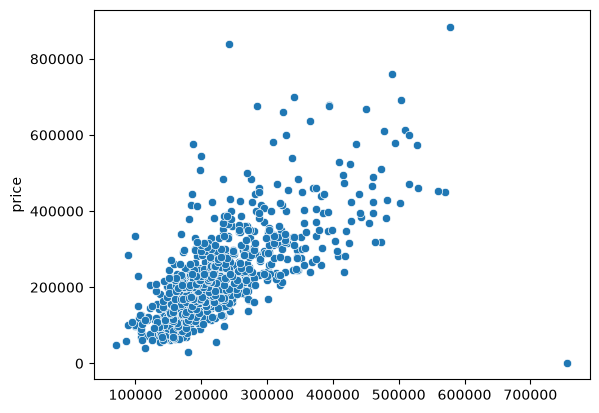

In [32]:
sns.scatterplot(data=type_dummies ,x=y_pred ,y=y)

### 13. List the five assumptions for an MLR model. 

Indicate which ones are the same as the assumptions for an SLR model. 

The five assumptions of a Multiple Linear Regression model are:

1. Linearity between predictors and the target variable (same as SLR).
2. Independence of observations (same as SLR).
3. Homoscedasticity, meaning constant variance of residuals (same as SLR).
4. Normally distributed residuals (same as SLR).
5. No multicollinearity between predictors (specific to MLR).

The first four assumptions are the same as Simple Linear Regression, while multicollinearity is an additional assumption for MLR because it uses multiple predictors.

### 14. Pick at least two assumptions and explain whether or not you believe them to be met for your model, and explain why.

1. Linearity:
I believe this assumption is mostly met. The scatter plot between square footage and price shows a positive linear relationship, where larger houses generally have higher prices. However, some outliers may slightly affect the linear relationship.

2. No multicollinearity:
This assumption is likely met because the predictors used in the model measure different aspects of the house. However, some correlation may exist between variables such as square footage, bedrooms, and bathrooms because larger houses usually have more rooms.

### 15. Regression Metrics

Implement a function called `r2_adj()` that will calculate $R^2_{adj}$ for a model.

The adjusted R-squared is calculated as $R^2_{adj} = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - k - 1} \right]$.

Unlike standard R-squared, which always increases when you add new variables, Adjusted R-squared will actually decrease if you add a useless variable to your model. This helps you find the simplest and most effective model.
- $R^2$: The standard R-squared value (coefficient of determination)
- $n$: The total number of observations (sample size)
- $k$: The number of independent variables (predictors) in your model

In [36]:
def r2_adj(X, y, r2):
    n = len(y)
    k = X.shape[1]

    adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
    return adjusted_r2

r2 = model.score(X, y)
print("Adjusted R2:", r2_adj(X, y, r2))

Adjusted R2: 0.4842444363610937


### 17. Metrics, metrics, everywhere...

Calculate and interpret at least three regression metrics. How well does your model perform?

In [37]:
rscore = r2_score(y,y_pred)
mean_absolute = mean_absolute_error(y,y_pred)
sq_error = np.sqrt(mean_squared_error(y,y_pred))
adjusted_r = r2_adj(X, y, r2)

print(rscore)
print(mean_absolute)
print(sq_error)
print(adjusted_r)

0.4867913774161007
59875.242045856845
85835.3438362166
0.4842444363610937


In [38]:
# The model was evaluated using R², Adjusted R², MAE, and RMSE.

# The R² score is approximately 0.487, meaning that the model explains about 49% of the variation in house prices.

# The Adjusted R² is approximately 0.484, which is close to the R² value, indicating that the predictors used in the model provide useful information.

# The MAE is about $59,875, meaning that the model's predictions are off by around $60,000 on average.

# The RMSE is higher than MAE because it penalizes larger errors. Overall, the model captures some relationship between house features and price, but additional variables may improve performance. --> -->

### 18. Model Iteration

Adjust your model by adding or removing a variable. Then calculate the same regression metrics as you used in question 17. Has your model performance increased or decreased?

**Guidance:**
1. Look at the correlation between the dependent and independent variables. Which two predictors are the most correlated with each other?
2. Drop the one you think is less useful and refit the model with the remaining features.
3. Compare the new R2 and RMSE to your original model from Q11/Q17.


In [40]:
X_new = type_dummies[['sq__ft' , 'type_Residential' , 'type_Multi-Family']]
y = type_dummies['price']

lr_new = LinearRegression()
lr_new.fit(X_new,y)
y_pred_new = lr_new.predict(X_new)

r2_new = r2_score(y,y_pred_new)
adjusted_r2_new = r2_adj(X_new,y,r2_new)
absolute_error_mean_new = mean_absolute_error(y, y_pred_new)
squared_error_mean_new = mean_squared_error(y, y_pred_new)**0.5

print(r2_new)
print(adjusted_r2_new )
print(absolute_error_mean_new)
print(squared_error_mean_new )

0.48665528477368325
0.4847469401074145
59824.02151166651
85846.72398837628


### 19. Add `city` as a feature

Use `OneHotEncoder` on the `city` column to add location as a feature. Since some cities only have 1-2 sales, group cities with fewer than 20 sales into `'Other'` first. Compare R2 and RMSE to the base model.

In [41]:
city_counts = housing['city'].value_counts()
city_counts

city
SACRAMENTO         422
ELK GROVE          107
CITRUS HEIGHTS      34
ANTELOPE            33
ROSEVILLE           28
RANCHO CORDOVA      21
NORTH HIGHLANDS     21
GALT                20
CARMICHAEL          20
FOLSOM              15
RIO LINDA           12
ORANGEVALE          11
FAIR OAKS            9
ROCKLIN              8
LINCOLN              6
PLACERVILLE          5
ELVERTA              4
WILTON               4
POLLOCK PINES        3
GOLD RIVER           3
AUBURN               3
EL DORADO HILLS      3
GRANITE BAY          3
RANCHO MURIETA       2
LOOMIS               2
EL DORADO            2
MATHER               1
GREENWOOD            1
MEADOW VISTA         1
CAMERON PARK         1
PENRYN               1
DIAMOND SPRINGS      1
COOL                 1
WALNUT GROVE         1
SLOUGHHOUSE          1
WEST SACRAMENTO      1
Name: count, dtype: int64

In [ ]:
cities_to_keep = city_counts[city_counts >= 20].index
housing['city_grouped'] = housing['city'].apply(lambda x: x if x in cities_to_keep else 'Other')

## Part 2: Sacramento Real Estate Deep Dive & Model Diagnostics

---

### 21. Beating the Baseline
A machine learning model is only useful if it performs better than a "naive guess". Create a baseline model:

Calculate the mean `price` of your training data to get the "Baseline" prediction, then, report how much money "on average" does your MLR model save us in pricing errors compared to just guessing using the average?

### 22. Which Feature Matters Most?
To explain our model accurately, we use **Feature Scaling** to force all features to be on a similar scale, allowing us to compare their "weight" equally.

Fit a new Linear Regression model on this **scaled** training data and find the new coefficients. Based on these scaled coefficients, which feature does the model actually rely on the most to determine a house's price?

### 23. Does the model generalize to the real world?
A model that perfectly memorizes the training data but fails completely on new unseen houses is useless. We call a model's ability to succeed on new data **Generalization**.

Using your scaled MLR model from Question 22:

* **Step 1:** Predict prices for the **training** set and calculate the training RMSE.

* **Step 2:** Predict prices for the **testing** set and calculate the testing RMSE.

Is the model performing significantly worse on the test data? What does this tell you about how the model generalizes?

### 24. The Bias-Variance Tradeoff

In machine learning, there is a constant battle between Bias and Variance:
* **High Bias (Underfitting):** The model is very simple. It performs poorly on the training data as well as on the testing data.
* **High Variance (Overfitting):** The model is very complex. It memorizes the training data (high R-squared) but performs terribly on unseen testing data.
* **The Sweet Spot:** The model performs well on both the training set and the test set, with very little drop-off in performance.

Looking back at the Train and Test metrics you calculated for your Multiple Linear Regression model, is your model suffering from High Bias, High Variance, or is it in the sweet spot? Explain your reasoning.

### 25. Force High Variance to compare the outcomes
Let's see what the Bias-Variance Tradeoff looks like when we break the model on purpose! 

If we use `OneHotEncoder` on the `city` column **without** grouping the rare cities into "Other", we will a lot of new columns. Many of these columns will only have 1 or 2 houses in them. Explain the gap between the Train R-squared and Test R-squared.

### 26. Interpreting & Explaining Results to Non-Technical Audiences
Data science is useless if the business doesn't understand your results. Avoid using technical jargon. How would you translate your model's performance for the executives?